In [1]:
import numpy as np
from scipy.integrate import quad 

import matplotlib.pyplot as plt

we want to calculate,

$$\int_{0}^{4}\sqrt[4]{15x^3+21x^2+41x+3}.e^{-0.5x} dx$$

In [2]:
def f1(x):
    return (15*x**3+21*x**2+41*x+3)**(1/4)*(np.exp(-0.5*x))

<>:3: SyntaxWarning: invalid escape sequence '\i'
<>:3: SyntaxWarning: invalid escape sequence '\i'
C:\Users\Aaditya Saini\AppData\Local\Temp\ipykernel_14456\1501958699.py:3: SyntaxWarning: invalid escape sequence '\i'
  plt.title("Plot of function: $\int_{0}^{4}\sqrt[4]{15x^3+21x^2+41x+3}.e^{-0.5x} dx$")


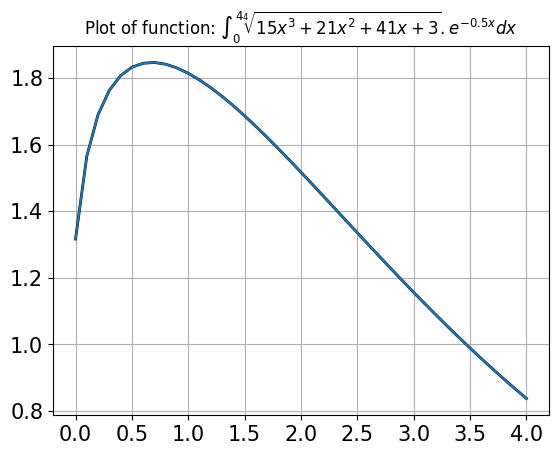

In [3]:
x=np.arange(0,4.1,0.1)
y=f1(x)
plt.title("Plot of function: $\int_{0}^{4}\sqrt[4]{15x^3+21x^2+41x+3}.e^{-0.5x} dx$")
plt.plot(x,y,'-',c='k',lw=2)
ax = plt.gca()
ax.grid(True)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.plot(x,y)

# Riemann sums 


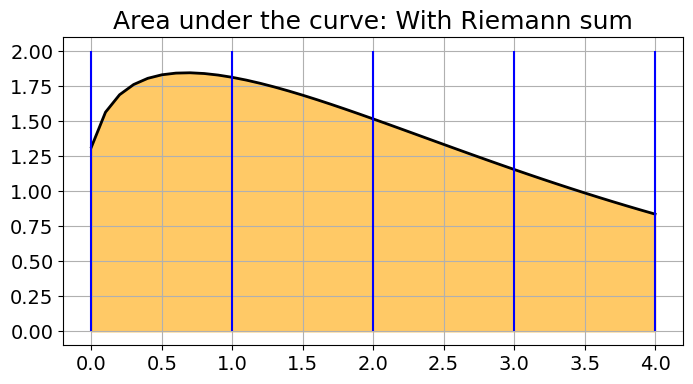

In [7]:
rect = np.linspace(0,4,5)

plt.figure(figsize=(8,4))
plt.title("Area under the curve: With Riemann sum",
         fontsize=18)
plt.plot(x,y,'-',c='k',lw=2)
plt.fill_between(x,y1=y,y2=0,color='orange',alpha=0.6)
for i in range(5):
    plt.vlines(x=rect[i],ymin=0,ymax=2,color='blue')
plt.grid(True)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

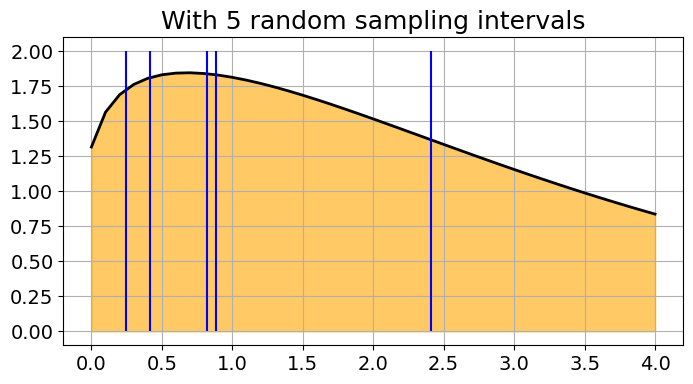

In [13]:
rand_lines = 4*np.random.uniform(size=5)

plt.figure(figsize=(8,4))
plt.title("With 5 random sampling intervals",
         fontsize=18)
plt.plot(x,y,'-',c='k',lw=2)
plt.fill_between(x,y1=y,y2=0,color='orange',alpha=0.6)
for i in range(5):
    plt.vlines(x=rand_lines[i],ymin=0,ymax=2,color='blue')
plt.grid(True)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [16]:
## simpler version 
def monte_carlo(func, a=0,b=1,n=1000):
   u=np.random.uniform(size=n)
   u_funct=func(a+(b-a)*u)
   s=((b-a)/n)*u_funct.sum()
   return s


In [18]:
inte = monte_carlo(f1,a=0,b=4,n=100)
print(inte)

5.611984527077712


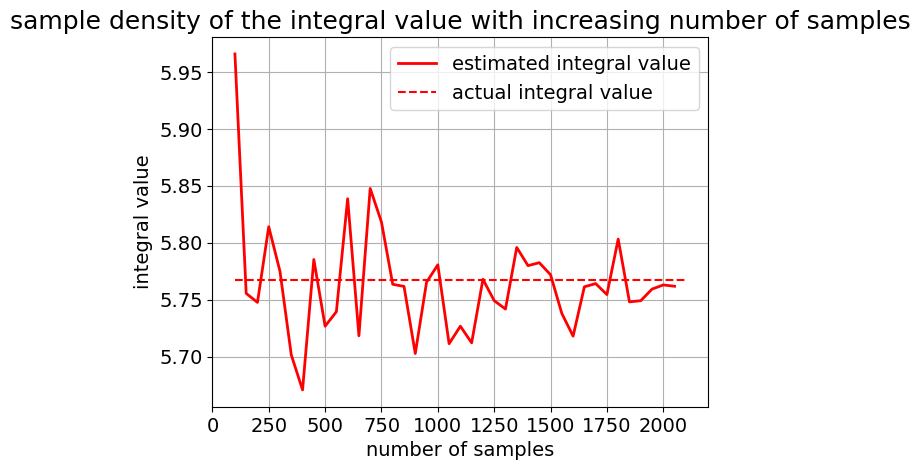

In [23]:
list=[]
for i in range (100,2100,50):
    inte=monte_carlo(f1,a=0,b=4,n=i)
    list.append(inte)

result = quad(f1,0,4)
plt.title("sample density of the integral value with increasing number of samples",
         fontsize=18)
plt.plot([i for i in range(100,2100,50)],list,'-',c='red',lw=2)
plt.hlines(y=result[0],xmin=100,xmax=2100,color='red',linestyle='--')   
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("number of samples",fontsize=14)
plt.ylabel("integral value",fontsize=14)    
plt.legend(["estimated integral value","actual integral value"],fontsize=14)
plt.grid(True)
plt.show()

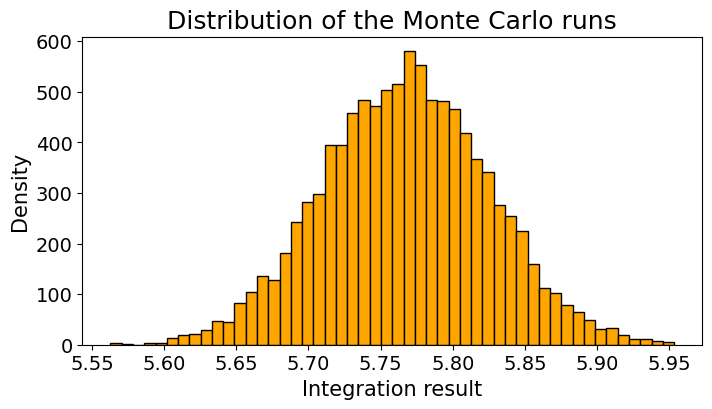

In [25]:
inte_lst = []
for i in range(10000):
    inte = monte_carlo(f1,a=0,b=4,n=500)
    inte_lst.append(inte)

plt.figure(figsize=(8,4))
plt.title("Distribution of the Monte Carlo runs",
         fontsize=18)
plt.hist(inte_lst,bins=50,color='orange',edgecolor='k')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Integration result",fontsize=15)
plt.ylabel("Density",fontsize=15)
plt.show()